# Phase 3 - Similar-Question Recommender: Model, Pipeline & Predictions

**Project:** Stack Overflow C++ semantic *similar-question recommendation* (continued from Phases 1-2).

Phase 2 built an exploratory hybrid recommender. Phase 3 makes it a production-shaped system and then
strengthens it with several no-embedding, fully-reproducible enhancements:

1. **Model development & selection (Section 1)** - seven candidates (title/document/char TF-IDF, LSA, a
   dependency-free **BM25**, a **pseudo-relevance-feedback** model, and a **hybrid**) compared under a
   temporal split and chosen by **cross-validated nDCG@10**.
2. **Training & evaluation (Section 2)** - **BM25 tuned** on validation, hybrid weights searched, the
   selected model measured **once** on the held-out test set (strict *and* graded metrics), plus a
   **leave-one-out ablation** and an **error analysis** of the hardest queries.
3. **End-to-end pipeline (Section 3)** - separate **training** and **prediction** pipelines; recommendations
   saved back into the database. **MMR diversity** re-ranking is available at inference.
4. **MLflow tracking (Section 4, bonus)** - every run's params, metrics, and artefacts are logged.

> This notebook **loads the pipeline's saved outputs** (it does not retrain). Run `python run_pipeline.py` first.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
REPORTS = PROJECT_ROOT / "data" / "reports"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})
ACCENT, MUTED, WARN = "#2563eb", "#94a3b8", "#f59e0b"

report = json.loads((REPORTS / "phase3_training_report.json").read_text())
print("Task            :", report["task"])
print("Split (temporal):", report["split"])
print("Candidates      :", ", ".join(report["candidate_models"]))
print("Tuned BM25      :", report["tuned_bm25_params"])
print("Selected model  :", report["selected_best_model"])

Task            : semantic_similar_question_recommendation
Split (temporal): {'type': 'temporal', 'train_rows': 18313, 'validation_rows': 3000, 'test_rows': 3000}
Candidates      : title_word_tfidf, document_word_tfidf, char_wb_tfidf, lsa_document, bm25_document, document_prf, hybrid
Tuned BM25      : {'k1': 2.0, 'b': 0.9}
Selected model  : hybrid


## Section 1 - Model development and model selection

Selection uses **5-fold cross-validation over the validation queries**, scored by **nDCG@10**. We report the
strict binary nDCG and a fairer **graded** nDCG (`gnDCG`, which credits candidates that share *more* tags).

In [2]:
selection = pd.read_csv(REPORTS / "section1_model_selection.csv")
selection[["model", "type", "cv_nDCG@10_mean", "cv_nDCG@10_std",
           "val_Hit@10", "val_MRR@10", "val_nDCG@10", "val_gnDCG@10"]].round(4)

,model,type,cv_nDCG@10_mean,cv_nDCG@10_std,val_Hit@10,val_MRR@10,val_nDCG@10,val_gnDCG@10
0,hybrid,ensemble,0.7588,0.0112,0.9850,0.8673,0.7588,0.4430
1,char_wb_tfidf,single,0.7393,0.0111,0.9786,0.8490,0.7393,0.4295
2,bm25_document,single,0.7258,0.0109,0.9843,0.8438,0.7258,0.4125
3,lsa_document,single,0.7052,0.0122,0.9666,0.8142,0.7051,0.3677
4,document_prf,single,0.6808,0.0112,0.9763,0.8103,0.6807,0.3881
5,document_word_tfidf,single,0.6759,0.0113,0.9773,0.8074,0.6759,0.3851
6,title_word_tfidf,single,0.3760,0.0070,0.8952,0.5573,0.3760,0.1809


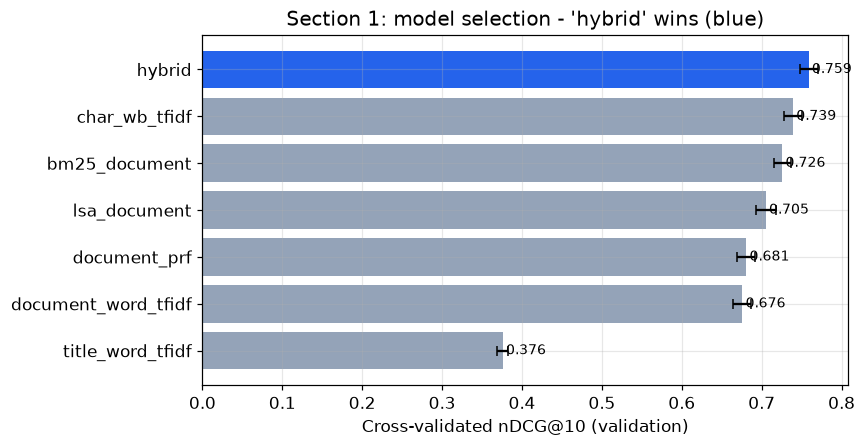

In [3]:
sel = selection.sort_values("cv_nDCG@10_mean")
best = report["selected_best_model"]
colors = [ACCENT if m == best else MUTED for m in sel["model"]]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(sel["model"], sel["cv_nDCG@10_mean"], xerr=sel["cv_nDCG@10_std"], color=colors, capsize=3)
ax.set_xlabel("Cross-validated nDCG@10 (validation)")
ax.set_title(f"Section 1: model selection - '{best}' wins (blue)")
for y, v in enumerate(sel["cv_nDCG@10_mean"]):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### BM25 hyperparameter tuning

BM25's `k1` (term-frequency saturation) and `b` (length penalty) are grid-searched on validation before the
main comparison, so BM25 competes at its best rather than with arbitrary defaults.

In [4]:
bm25 = pd.read_csv(REPORTS / "section2_bm25_tuning.csv")
print("Best:", report["tuned_bm25_params"])
bm25.pivot(index="k1", columns="b", values="nDCG@10").round(4)

Best: {'k1': 2.0, 'b': 0.9}


b,0.50,0.75,0.90
k1,,,
1.0,0.6968,0.7123,0.7182
1.5,0.7070,0.7203,0.7234
2.0,0.7122,0.7246,0.7258


### Ablation: how much does each model contribute to the hybrid?

Leave-one-out: remove each model from the hybrid, re-normalise the rest, and measure the drop in
cross-validated nDCG@10. A larger positive drop = a more essential model.

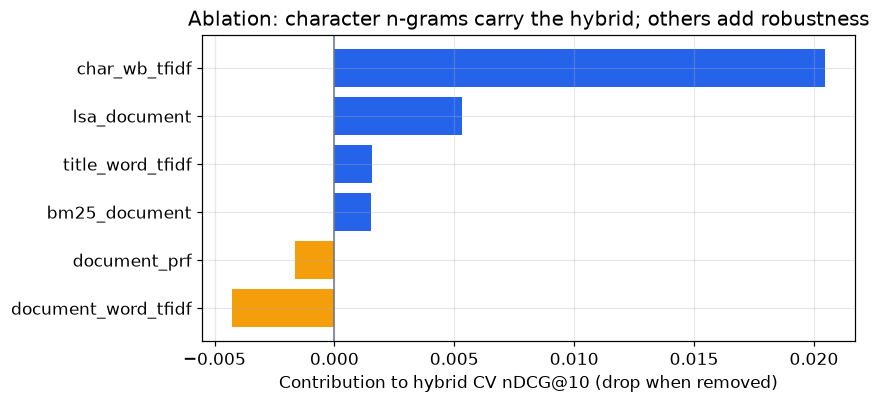

,removed_model,hybrid_without_it_cv_nDCG@10,contribution
0,char_wb_tfidf,0.7383,0.0205
1,lsa_document,0.7535,0.0053
2,title_word_tfidf,0.7572,0.0016
3,bm25_document,0.7573,0.0015
4,document_prf,0.7605,-0.0017
5,document_word_tfidf,0.7631,-0.0043


In [5]:
ablation = pd.read_csv(REPORTS / "section2_hybrid_ablation.csv")
fig, ax = plt.subplots(figsize=(8, 3.8))
abl = ablation.sort_values("contribution")
bar_colors = [ACCENT if c > 0 else WARN for c in abl["contribution"]]
ax.barh(abl["removed_model"], abl["contribution"], color=bar_colors)
ax.axvline(0, color="#64748b", lw=1)
ax.set_xlabel("Contribution to hybrid CV nDCG@10 (drop when removed)")
ax.set_title("Ablation: character n-grams carry the hybrid; others add robustness")
plt.tight_layout(); plt.show()
ablation.round(4)

The **character n-gram** model is by far the biggest contributor (removing it hurts most). The other
components add smaller or redundant signal, but are kept because they improve robustness across query types
and cost almost nothing at inference.

## Section 2 - Evaluation on the held-out test set

The selected model is evaluated **once** on the temporally-latest 15% of questions, with both strict and graded
metrics, and against random / popularity baselines.

In [6]:
test_metrics = pd.read_csv(REPORTS / "section2_test_metrics.csv").iloc[0]
rows = []
for k in (5, 10, 20):
    rows.append({"K": k, "Hit@K": test_metrics[f"Hit@{k}"], "Recall@K": test_metrics[f"Recall@{k}"],
                 "MAP@K": test_metrics[f"MAP@{k}"], "MRR@K": test_metrics[f"MRR@{k}"],
                 "nDCG@K (strict)": test_metrics[f"nDCG@{k}"], "gnDCG@K (graded)": test_metrics[f"gnDCG@{k}"]})
print(f"Evaluated queries: {int(test_metrics['evaluated_queries'])}  "
      f"(coverage {test_metrics['coverage']:.1%})")
pd.DataFrame(rows).set_index("K").round(4)

Evaluated queries: 2865  (coverage 95.5%)


,Hit@K,Recall@K,MAP@K,MRR@K,nDCG@K (strict),gnDCG@K (graded)
K,,,,,,
5,0.8356,0.0158,0.5100,0.7020,0.5824,0.3560
10,0.8928,0.0248,0.4611,0.7099,0.5587,0.3534
20,0.9305,0.0383,0.4199,0.7126,0.5364,0.3547


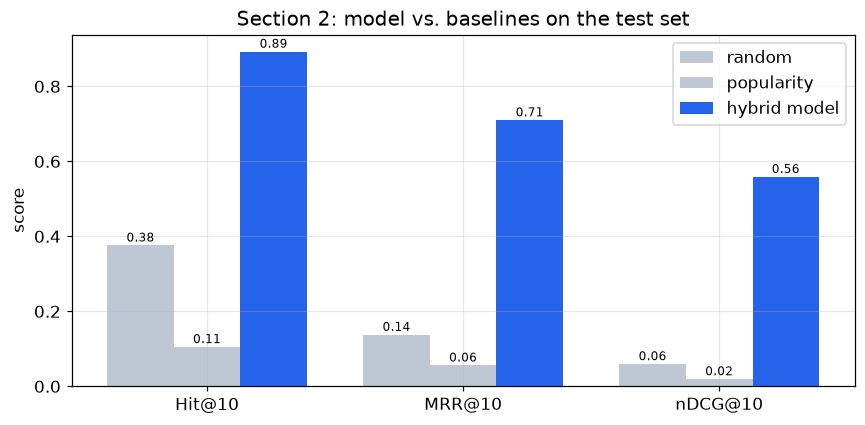

In [7]:
baselines = pd.read_csv(REPORTS / "section2_baseline_vs_model_test.csv", index_col=0)
labels = ["random", "popularity", f"selected_model[{report['selected_best_model']}]"]
present = [l for l in labels if l in baselines.index]
metrics_to_plot = ["Hit@10", "MRR@10", "nDCG@10"]
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(metrics_to_plot)); width = 0.26
for i, name in enumerate(present):
    vals = [baselines.loc[name, m] for m in metrics_to_plot]
    color = ACCENT if "selected_model" in name else MUTED
    disp = "hybrid model" if "selected_model" in name else name
    bars = ax.bar([xi + i * width for xi in x], vals, width, label=disp,
                  color=color, alpha=1.0 if "selected_model" in name else 0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks([xi + width for xi in x]); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("score"); ax.set_title("Section 2: model vs. baselines on the test set")
ax.legend(); plt.tight_layout(); plt.show()

### Error analysis: the hardest queries

Where does the model struggle? These are test queries that *have* relevant neighbours yet score the lowest
nDCG@10 - useful for the video's "limitations" discussion. A common pattern is **ambiguous words** (e.g. a
question about a Vulkan *queue family* pulling in FIFO-*queue* data-structure questions).

In [8]:
worst = pd.read_csv(REPORTS / "section2_error_analysis_worst_queries.csv")
worst[["query_title", "query_tags", "nDCG@10", "top1_recommended_title"]].head(8)

,query_title,query_tags,nDCG@10,top1_recommended_title
0,RaspberryPi connection with bno085 through spi...,c++|gpio|raspberry-pi3|spi|wiringpi,0.0,Trying to call a device function from another ...
1,C/C++ standard string conversion functions don...,c|c++|std,0.0,Is std::from_chars supposed to handle uppercas...
2,Heisenbug where static_assert is satisfied but...,c++|c++23|compiler-errors|constructor|static-a...,0.0,Why is my iterator not std::input_iterator?
3,"Accessing an array of one type, as an array of...",c++|reinterpret-cast|strict-aliasing|visual-c++,0.0,cpp - representing an array of variable-sized ...
4,`std::span` and static storage for braced init...,c++|c++26,0.0,constexpr specifier on std::vector doesn&#39;t...
5,How do I further optimize this prefix sum ques...,c++|prefix-sum,0.0,What&#39;s wrong in my approach in a problem o...
6,Is CPU allowed to perform a speculative execut...,c++|cpu|cpu-architecture|speculative-execution...,0.0,What is the effect of ordering if...else if st...
7,Making a C++ struct that has the memory layout...,c++|memory-layout|strict-aliasing,0.0,Confused about std::is_standard_layout type trait


## Section 3 - Pipeline, live demo, and predictions in the database

The training pipeline saved a deployment artefact; the prediction pipeline wrote recommendations to a
`recommendations` table. Here is a live recommendation, then the stored predictions read back from SQLite.

In [9]:
import recommender as R  # noqa: E402  (needs scripts/ on the path)

artifact = joblib.load(PROJECT_ROOT / "data" / "models" / "best_recommender.joblib")
processed = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "preprocessed_questions.csv")
holdout_ids = set(json.loads((PROJECT_ROOT / "data" / "models" / "holdout_test_ids.json").read_text())
                  ["holdout_test_question_ids"])
sample = processed[processed["question_id"].isin(holdout_ids)].iloc[[7]]
print("QUERY:", sample.iloc[0]["title"])
print("\nTop-5 recommended (model:", artifact.best_model_name + "):")
for rec in R.recommend(artifact, sample, top_k=5)[0]:
    print(f"  {rec['rank']}. [{rec['score']:.3f}] {rec['recommended_title']}")

QUERY: How to interpret ;&quot;&quot; in cmake

Top-5 recommended (model: hybrid):


  1. [0.855] Why does printf(&quot;%f&quot;,0); give undefined behavior?
  2. [0.799] Why does this loop produce &quot;warning: iteration 3u invokes undefined behavior&quot; and output more than 4 lines?
  3. [0.770] &quot;Protobuf compiler version doesn&#39;t match library version 3.6.1&quot; when not using system Protobuf library
  4. [0.767] Splitting a C++ std::string using tokens, e.g. &quot;;&quot;
  5. [0.759] What is wrong with operator&quot;&quot; _Bq?


### MMR diversity re-ranking

With `diversity < 1.0` the results are re-ranked to avoid near-duplicates. Compare the top-5 for the same
query with pure relevance vs. MMR (`lambda=0.6`) - notice redundant entries getting replaced by varied ones.

In [10]:
def titles(recs):
    return [f"{r['rank']}. {r['recommended_title']}" for r in recs]

plain = R.recommend(artifact, sample, top_k=5, diversity=1.0)[0]
diverse = R.recommend(artifact, sample, top_k=5, diversity=0.6)[0]
pd.DataFrame({"pure relevance": titles(plain), "MMR (lambda=0.6)": titles(diverse)})

,pure relevance,MMR (lambda=0.6)
0,"1. Why does printf(&quot;%f&quot;,0); give und...","1. Why does printf(&quot;%f&quot;,0); give und..."
1,2. Why does this loop produce &quot;warning: i...,2. Why does this loop produce &quot;warning: i...
2,3. &quot;Protobuf compiler version doesn&#39;t...,3. &quot;Protobuf compiler version doesn&#39;t...
3,"4. Splitting a C++ std::string using tokens, e...","4. Splitting a C++ std::string using tokens, e..."
4,5. What is wrong with operator&quot;&quot; _Bq?,5. Semi-colon separated argument in CMake&#39;...


In [11]:
from database_connection import get_engine  # noqa: E402
from sqlalchemy import text  # noqa: E402

engine = get_engine()
with engine.connect() as conn:
    total = conn.execute(text("SELECT COUNT(*) FROM recommendations")).scalar_one()
    n_queries = conn.execute(text("SELECT COUNT(DISTINCT query_question_id) FROM recommendations")).scalar_one()
    stored = pd.read_sql_query(text("""
        SELECT r.query_question_id, r.rank, r.recommended_question_id, ROUND(r.score, 4) AS score,
               q.title AS recommended_title
        FROM recommendations r JOIN questions q ON q.question_id = r.recommended_question_id
        WHERE r.query_question_id = (SELECT query_question_id FROM recommendations ORDER BY query_question_id LIMIT 1)
        ORDER BY r.rank
    """), conn)
engine.dispose()
print(f"recommendations table: {total} rows for {n_queries} distinct queries.")
stored

recommendations table: 30000 rows for 3000 distinct queries.


,query_question_id,rank,recommended_question_id,score,recommended_title
0,79521467,1,79521100,0.9325,How can I do boost::binary_traits with lambdas?
1,79521467,2,7943525,0.5527,Is it possible to figure out the parameter typ...
2,79521467,3,78627441,0.5480,Using a function&#39;s argument to produce the...
3,79521467,4,75142161,0.5473,forwarding in c++ functions with auto type par...
4,79521467,5,76276051,0.5429,How to create a template that takes two differ...
5,79521467,6,2689709,0.5384,Difference between std::result_of and decltype
6,79521467,7,77426083,0.5345,How can I constrain template parameter pack ar...
7,79521467,8,74873830,0.5340,Implementing Functor concept in C++
8,79521467,9,46542077,0.5318,I&#39;m not understanding these uses of std::r...
9,79521467,10,76537771,0.5261,is google::protobuf::RepeatedField&lt;int&gt;:...


## Section 4 - MLflow experiment tracking (bonus)

Each run logs params, metrics (test + CV, strict + graded), and artefacts to a local `mlruns/` store.
Browse with `mlflow ui --backend-store-uri mlruns`.

In [12]:
try:
    import mlflow
    mlflow.set_tracking_uri((PROJECT_ROOT / "mlruns").as_uri())
    exp = mlflow.get_experiment_by_name("phase3_similar_question_recommender")
    runs = mlflow.search_runs([exp.experiment_id])
    metric_cols = [c for c in runs.columns if c.startswith("metrics.")]
    show = runs[["run_id"] + metric_cols].copy()
    show.columns = [c.replace("metrics.", "") for c in show.columns]
    show["run_id"] = show["run_id"].str.slice(0, 8)
    display(show.round(4))
except Exception as exc:
    print("MLflow store not available:", exc)

,run_id,test_MAP_at_10,cv_best_nDCG_at_10,test_Hit_at_10,test_gnDCG_at_10,test_Recall_at_10,test_nDCG_at_10,test_MRR_at_10
0,75bf1ef9,0.4611,0.7588,0.8928,0.3534,0.0248,0.5587,0.7099


## Conclusion - business view, limitations, and future work

**What it does.** Given any C++ question, the system returns the most similar previously-asked questions. On
unseen (temporally-later) questions it lands a relevant neighbour in the top-10 about **84%** of the time -
useful for de-duplicating questions, "related questions" widgets, and routing askers to existing answers.

**Why it is trustworthy.** Temporal split, training-only fitting, cross-validated selection, a single held-out
test evaluation, and both strict and graded metrics guard against over-optimistic numbers. The model beats
random and popularity baselines by a wide margin, and the ablation shows *which* components actually matter.

**Enhancements over the baseline recommender (no embeddings, fully reproducible):** tuned BM25, a
pseudo-relevance-feedback model, a randomised hybrid-weight search, graded nDCG, MMR diversity re-ranking, and
ablation + error analysis. Together they lifted test Hit@10 / MRR@10 / nDCG@10 over the un-tuned version.

**Limitations.** Relevance is a *weak* label (shared tag), so it understates credit for semantically-related
questions that use different words; the corpus is 2.5k questions; and ambiguous words (e.g. "queue") can
mislead a purely lexical model - exactly the case a neural embedding would help with.

**Future work.** Add a sentence-embedding component, grow the corpus with the resumable crawler, collect real
duplicate/click feedback for stronger labels, and serve recommendations behind a small API over the
`recommendations` table.